In [3]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# ============================================================
# CELL 2 — LOAD CLEAN DATASET
# ============================================================

DATASET_PATH = "../../parquet_exports_v2/retrieval_clean_ready_v2.parquet"

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED
Rows    : 108,421
Columns : 31


,rag_id,problem_text_clean,solution_text_clean,category,priority,language,product,queue,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,is_sla_breached,is_escalated,escalation_risk_level,issue_complexity_score,sla_risk_score,problem_word_count,problem_char_count,problem_repetition_ratio,solution_word_count,solution_char_count,solution_repetition_ratio,source_system,source_dataset,created_at,resolved_at
0,45d0726cc395d2b3a2b8c9899523e1dc,i am unable to access my account after enterin...,security settings updated and customer notifie...,performance issue,critical,french,Subscription Service,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,low,4.0,3.75,24,145,0.5,9,74,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2022-09-08,2022-09-08
1,504f35fd3b03f048a1984f89fffb08e1,i would like to request a refund for the recen...,explained billing breakdown and clarified appl...,login issue,medium,french,E-commerce Store,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,low,2.0,2.80,22,111,0.5,7,61,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2023-09-25,2023-09-28
2,db7bc1e2f75fa986ee832c31e320a2de,there seems to be a discrepancy in my billing ...,provided step-by-step troubleshooting instruct...,refund request,high,english,Cloud Storage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,low,7.0,4.00,26,143,0.5,7,70,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2023-06-21,2023-06-21
3,01d7f2addbcc200f88368695230ea06e,the system is not syncing data across devices ...,bug logged internally and workaround shared wi...,payment problem,low,chinese,Analytics Dashboard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,low,6.0,2.95,18,111,0.5,9,62,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2023-03-13,2023-03-25
4,aa219338e9e467aadb53d3d1a9026de7,i am unable to access my account after enterin...,provided step-by-step troubleshooting instruct...,security concern,low,german,Cloud Storage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,low,7.0,3.30,24,145,0.5,7,70,0.0,customer_support_tickets_200k,customer_support_tickets_200k,2024-10-12,2024-10-21


In [5]:
print("=" * 60)
print("DATA VALIDATION")
print("=" * 60)

print(f"Rows: {len(df):,}")

if "problem_text_clean" in df.columns:
    print("\nproblem_text_clean stats:")
    print(f"  Empty texts: {(df['problem_text_clean'].fillna('').str.strip() == '').sum()}")
    print(f"  Average length: {df['problem_text_clean'].str.len().mean():.2f}")

if "solution_text_clean" in df.columns:
    print("\nsolution_text_clean stats:")
    print(f"  Empty texts: {(df['solution_text_clean'].fillna('').str.strip() == '').sum()}")
    print(f"  Average length: {df['solution_text_clean'].str.len().mean():.2f}")

DATA VALIDATION
Rows: 108,421

problem_text_clean stats:
  Empty texts: 0
  Average length: 208.74

solution_text_clean stats:
  Empty texts: 0
  Average length: 149.88


In [6]:
# ============================================================
# CELL 4 — GLOBAL VISUAL STYLE
# ============================================================

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)

print("Visualization style configured.")

Visualization style configured.


In [7]:
print("=" * 60)
print("TEXT LENGTH OUTLIERS")
print("=" * 60)

if "problem_word_count" in df.columns:
    print("\n--- problem_word_count ---")
    display(
        df["problem_word_count"].describe(
            percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]
        )
    )

if "solution_word_count" in df.columns:
    print("\n--- solution_word_count ---")
    display(
        df["solution_word_count"].describe(
            percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]
        )
    )

TEXT LENGTH OUTLIERS

--- problem_word_count ---


count    108421.000000
mean         32.154140
std          22.829683
min           5.000000
25%          20.000000
50%          22.000000
75%          26.000000
90%          75.000000
95%          90.000000
99%         107.000000
max         201.000000
Name: problem_word_count, dtype: float64


--- solution_word_count ---


count    108421.000000
mean         22.114646
std          25.638755
min           5.000000
25%           8.000000
50%           9.000000
75%          16.000000
90%          72.000000
95%          85.000000
99%         101.000000
max         136.000000
Name: solution_word_count, dtype: float64

In [8]:
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

if "problem_text_clean" in df.columns:
    dup_problem = df["problem_text_clean"].duplicated().sum()
    print(f"Duplicate problem_text_clean: {dup_problem:,} ({(dup_problem/len(df))*100:.2f}%)")

if "solution_text_clean" in df.columns:
    dup_solution = df["solution_text_clean"].duplicated().sum()
    print(f"Duplicate solution_text_clean: {dup_solution:,} ({(dup_solution/len(df))*100:.2f}%)")

DUPLICATE ANALYSIS
Duplicate problem_text_clean: 79,989 (73.78%)
Duplicate solution_text_clean: 79,996 (73.78%)


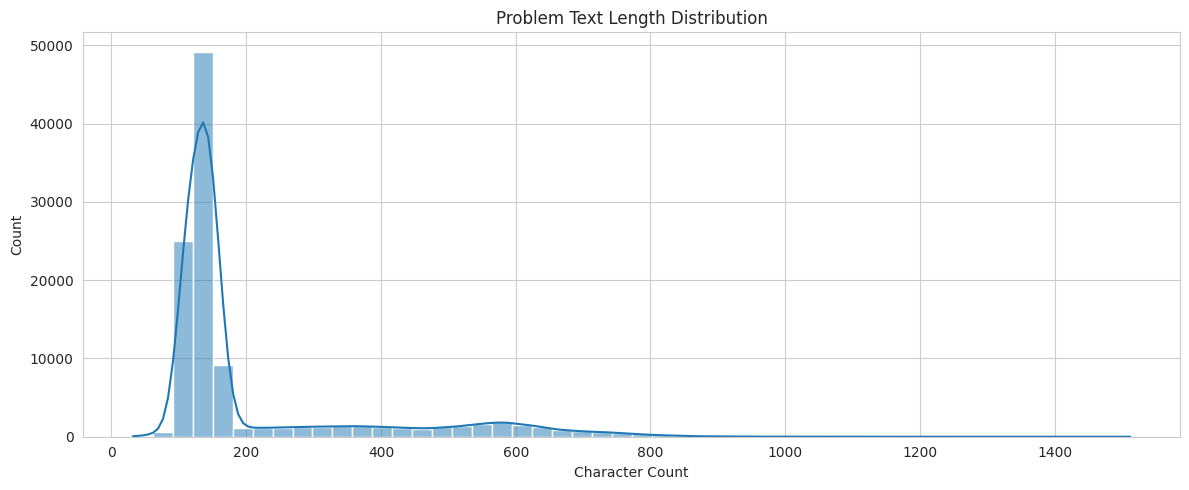

In [9]:
# ============================================================
# CELL 7 — PROBLEM TEXT LENGTH DISTRIBUTION
# ============================================================

if "problem_text_clean" in df.columns:
    text_lengths = df["problem_text_clean"].str.len()

    plt.figure(figsize=(12, 5))

    sns.histplot(
        text_lengths,
        bins=50,
        kde=True
    )

    plt.title("Problem Text Length Distribution")
    plt.xlabel("Character Count")

    plt.tight_layout()
    plt.show()

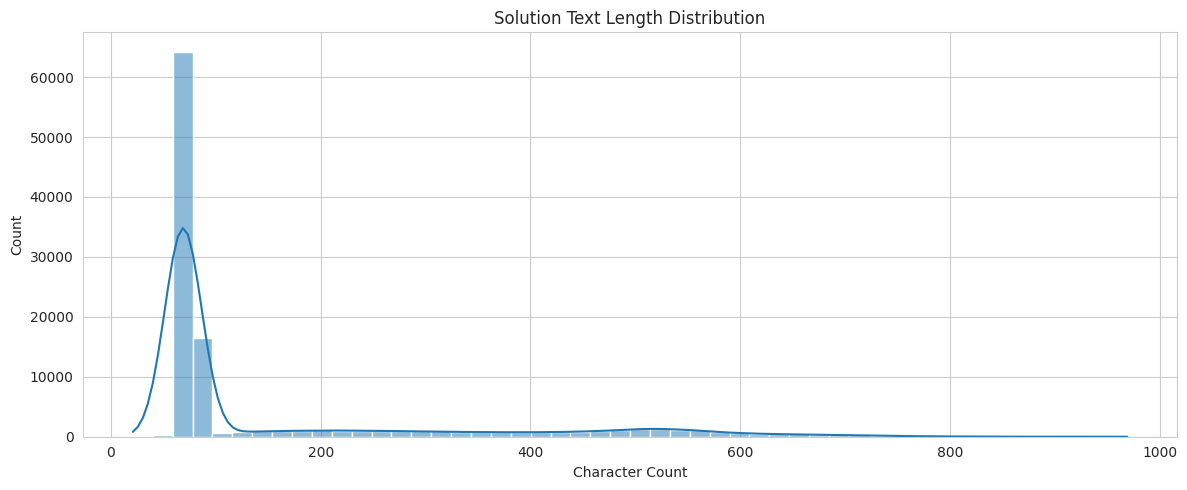

In [10]:
# ============================================================
# CELL 8 — SOLUTION TEXT LENGTH DISTRIBUTION
# ============================================================

if "solution_text_clean" in df.columns:
    text_lengths = df["solution_text_clean"].str.len()

    plt.figure(figsize=(12, 5))

    sns.histplot(
        text_lengths,
        bins=50,
        kde=True
    )

    plt.title("Solution Text Length Distribution")
    plt.xlabel("Character Count")

    plt.tight_layout()
    plt.show()

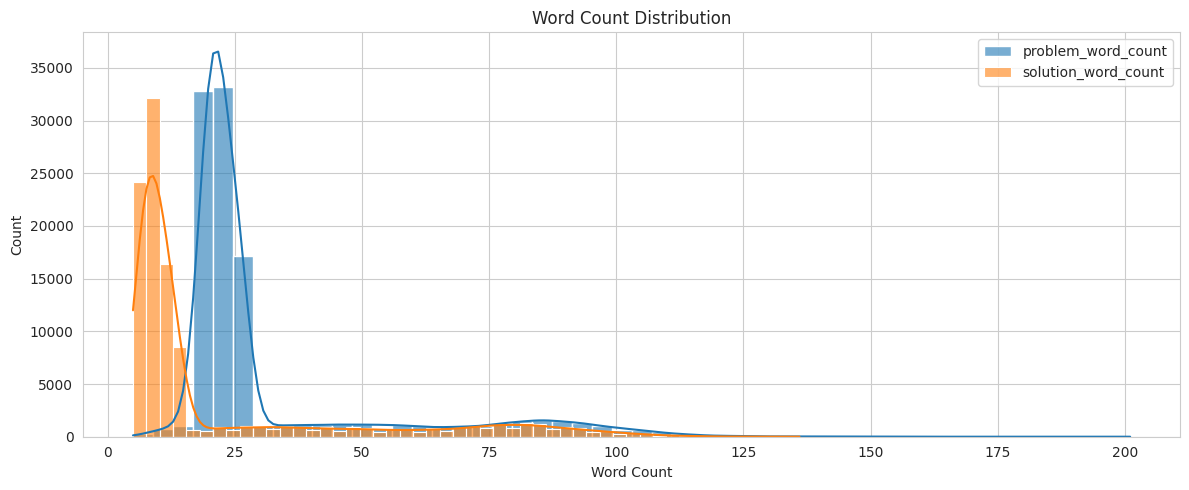

In [11]:
# ============================================================
# CELL 9 — WORD COUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 5))

if "problem_word_count" in df.columns:
    sns.histplot(
        df["problem_word_count"],
        bins=50,
        kde=True,
        alpha=0.6,
        label="problem_word_count"
    )

if "solution_word_count" in df.columns:
    sns.histplot(
        df["solution_word_count"],
        bins=50,
        kde=True,
        alpha=0.6,
        label="solution_word_count"
    )

plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.legend()

plt.tight_layout()
plt.show()

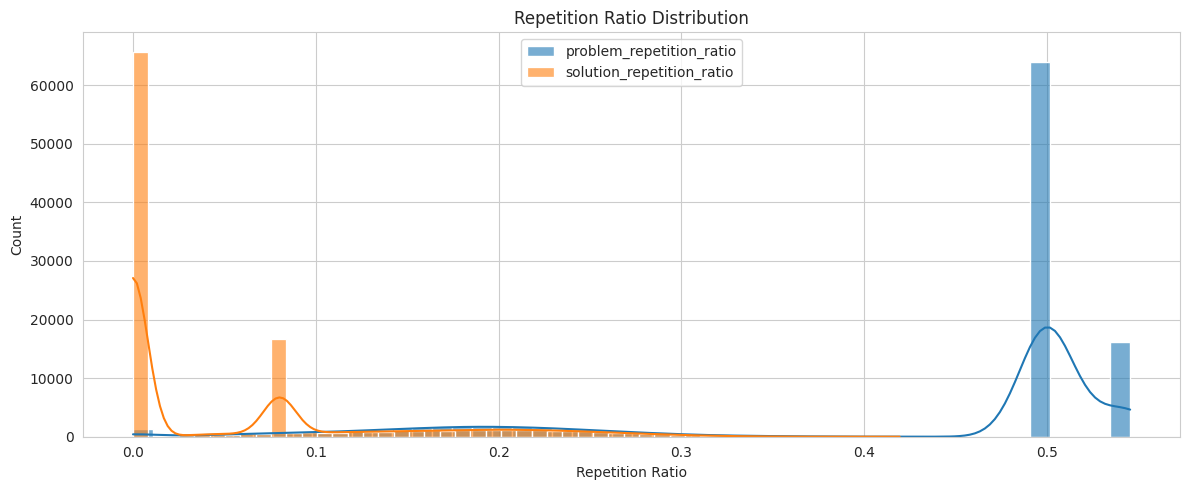

In [12]:
# ============================================================
# CELL 10 — REPETITION RATIO DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 5))

if "problem_repetition_ratio" in df.columns:
    sns.histplot(
        df["problem_repetition_ratio"],
        bins=50,
        kde=True,
        alpha=0.6,
        label="problem_repetition_ratio"
    )

if "solution_repetition_ratio" in df.columns:
    sns.histplot(
        df["solution_repetition_ratio"],
        bins=50,
        kde=True,
        alpha=0.6,
        label="solution_repetition_ratio"
    )

plt.title("Repetition Ratio Distribution")
plt.xlabel("Repetition Ratio")
plt.legend()

plt.tight_layout()
plt.show()

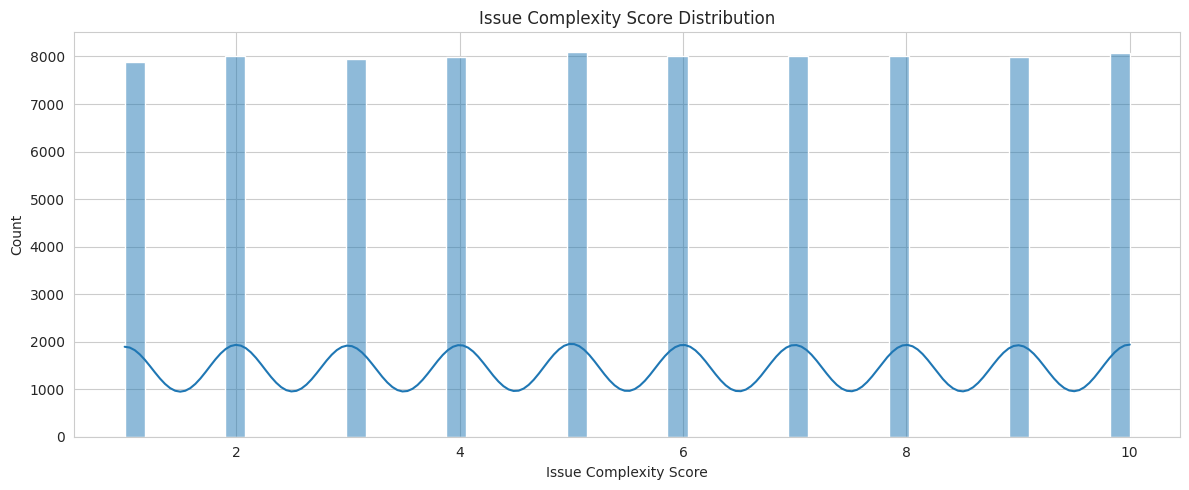

In [13]:
# ============================================================
# CELL 11 — ISSUE COMPLEXITY SCORE DISTRIBUTION
# ============================================================

if "issue_complexity_score" in df.columns:

    plt.figure(figsize=(12, 5))

    sns.histplot(
        df["issue_complexity_score"].dropna(),
        bins=50,
        kde=True
    )

    plt.title("Issue Complexity Score Distribution")
    plt.xlabel("Issue Complexity Score")

    plt.tight_layout()
    plt.show()

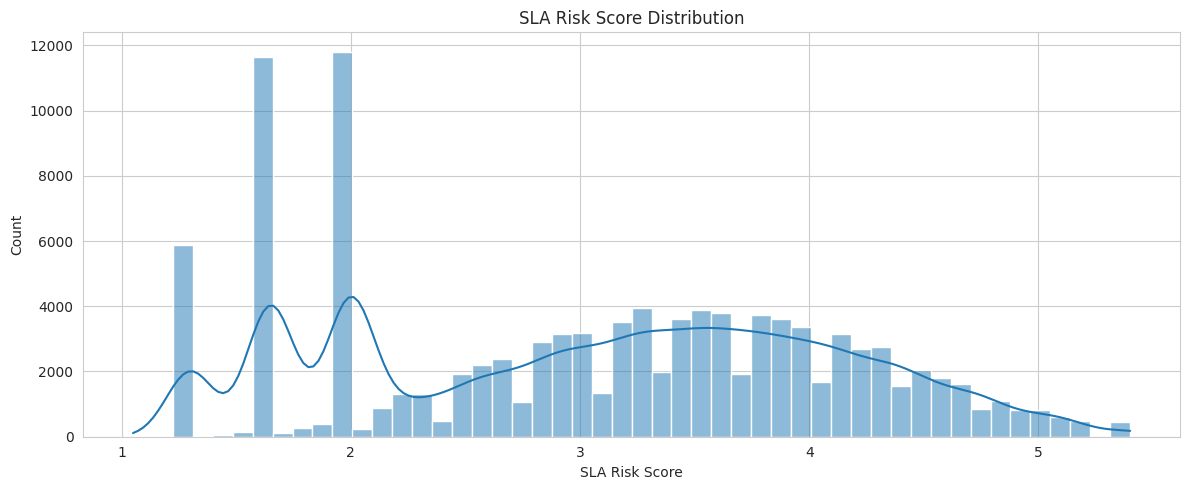

In [14]:
# ============================================================
# CELL 12 — SLA RISK SCORE DISTRIBUTION
# ============================================================

if "sla_risk_score" in df.columns:

    plt.figure(figsize=(12, 5))

    sns.histplot(
        df["sla_risk_score"].dropna(),
        bins=50,
        kde=True
    )

    plt.title("SLA Risk Score Distribution")
    plt.xlabel("SLA Risk Score")

    plt.tight_layout()
    plt.show()

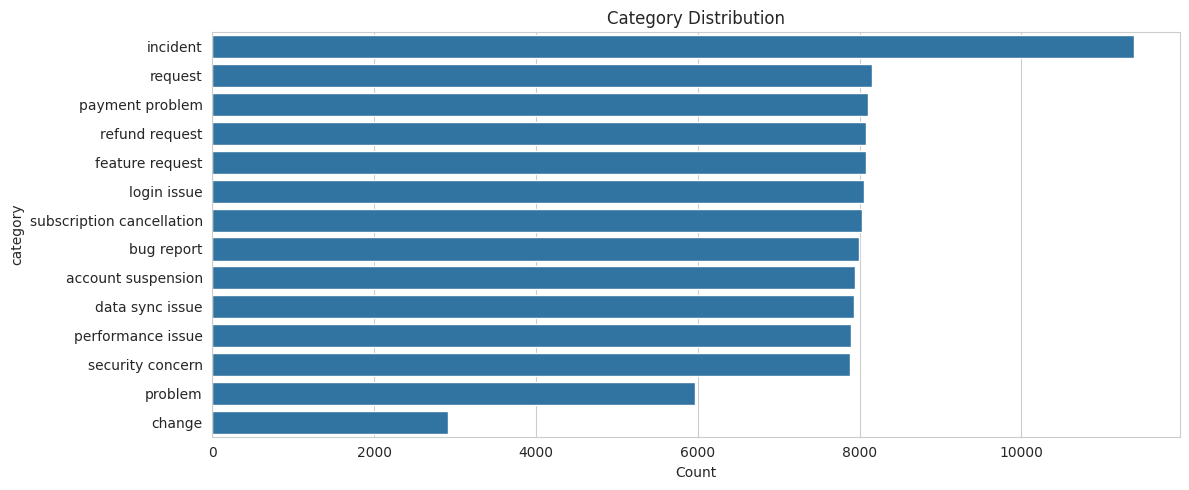

In [15]:
# ============================================================
# CELL 13 — CATEGORY DISTRIBUTION
# ============================================================

if "category" in df.columns:

    plt.figure(figsize=(12, 5))

    category_counts = df["category"].value_counts()

    sns.barplot(
        x=category_counts.values,
        y=category_counts.index
    )

    plt.title("Category Distribution")
    plt.xlabel("Count")

    plt.tight_layout()
    plt.show()

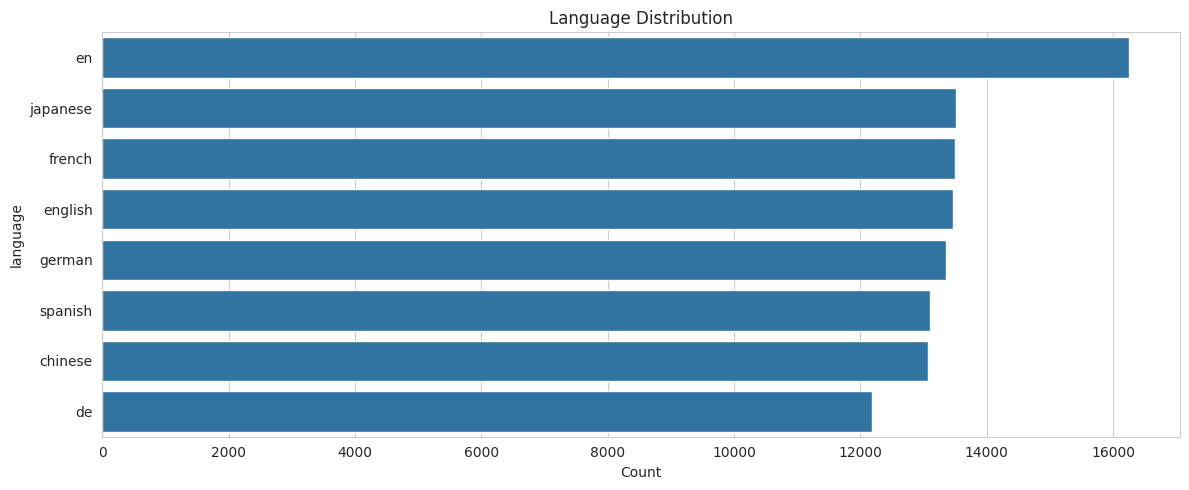

In [16]:
# ============================================================
# CELL 14 — LANGUAGE DISTRIBUTION
# ============================================================

if "language" in df.columns:

    plt.figure(figsize=(12, 5))

    lang_counts = df["language"].value_counts()

    sns.barplot(
        x=lang_counts.values,
        y=lang_counts.index
    )

    plt.title("Language Distribution")
    plt.xlabel("Count")

    plt.tight_layout()
    plt.show()

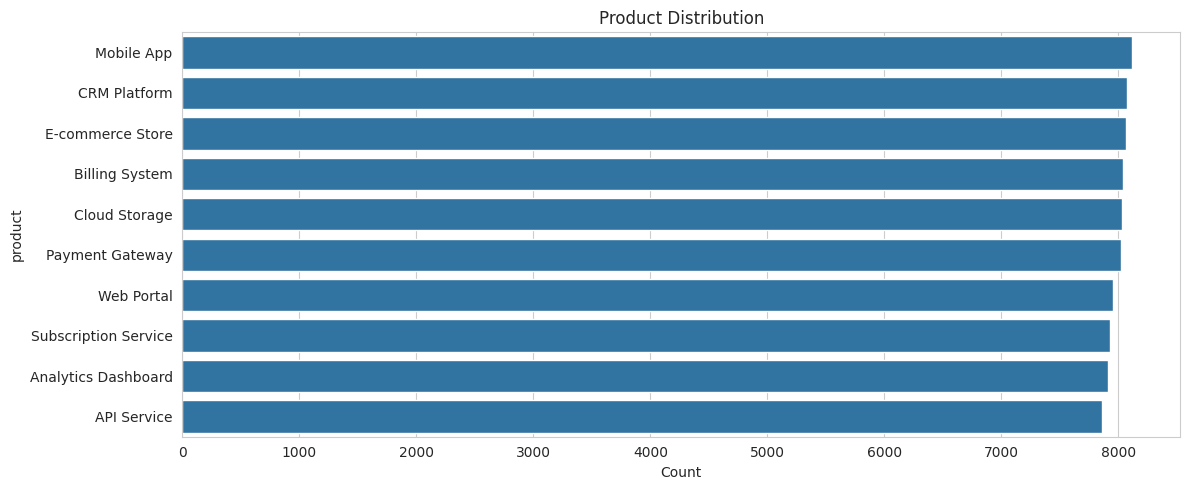

In [17]:
# ============================================================
# CELL 15 — PRODUCT DISTRIBUTION
# ============================================================

if "product" in df.columns:

    plt.figure(figsize=(12, 5))

    product_counts = df["product"].value_counts()

    sns.barplot(
        x=product_counts.values,
        y=product_counts.index
    )

    plt.title("Product Distribution")
    plt.xlabel("Count")

    plt.tight_layout()
    plt.show()


--- source_system ---
source_system
customer_support_tickets_200k    79999
dataset_tickets_multi_lang       28422
Name: count, dtype: int64

--- source_dataset ---
source_dataset
customer_support_tickets_200k    79999
dataset_tickets_multi_lang       28422
Name: count, dtype: int64


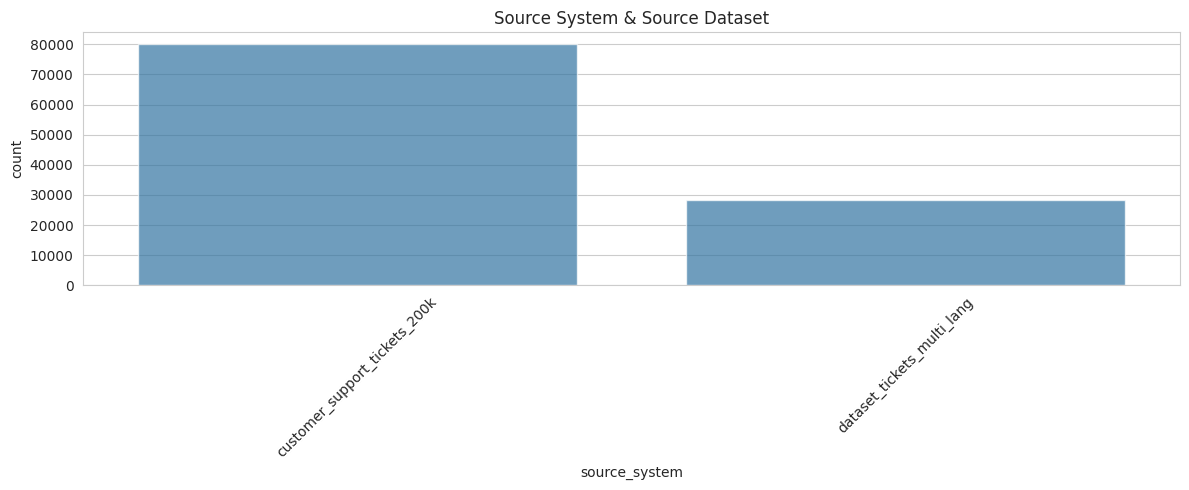

In [18]:
# ============================================================
# CELL 16 — SOURCE SYSTEM & SOURCE DATASET DISTRIBUTION
# ============================================================

if "source_system" in df.columns:
    print("\n--- source_system ---")
    print(df["source_system"].value_counts())

if "source_dataset" in df.columns:
    print("\n--- source_dataset ---")
    print(df["source_dataset"].value_counts())

if "source_system" in df.columns or "source_dataset" in df.columns:
    plt.figure(figsize=(12, 5))

    if "source_system" in df.columns:
        sns.countplot(data=df, x="source_system", alpha=0.7)

    plt.title("Source System & Source Dataset")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


PRIORITY DISTRIBUTION


priority
critical    18.54
high        28.70
low         23.74
medium      29.02
Name: proportion, dtype: float64

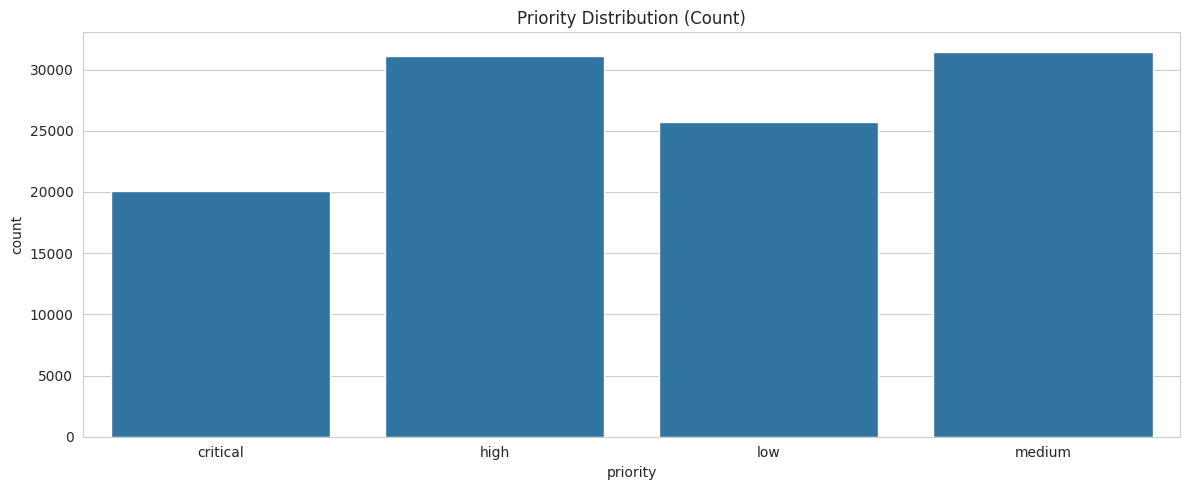

In [19]:
# ============================================================
# CELL 17 — PRIORITY & PRIORITY_TIER DISTRIBUTION
# ============================================================

TARGET_COLUMNS = [
    "priority",
    "priority_tier"
]

for col in TARGET_COLUMNS:

    if col in df.columns:

        print("\n" + "=" * 60)
        print(f"{col.upper()} DISTRIBUTION")
        print("=" * 60)

        distribution = (
            df[col]
            .value_counts(normalize=True)
            .sort_index()
            * 100
        ).round(2)

        display(distribution)

if "priority" in df.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x="priority", order=sorted(df["priority"].dropna().unique()))
    plt.title("Priority Distribution (Count)")
    plt.tight_layout()
    plt.show()

if "priority_tier" in df.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x="priority_tier", order=sorted(df["priority_tier"].dropna().unique()))
    plt.title("Priority Tier Distribution (Count)")
    plt.tight_layout()
    plt.show()

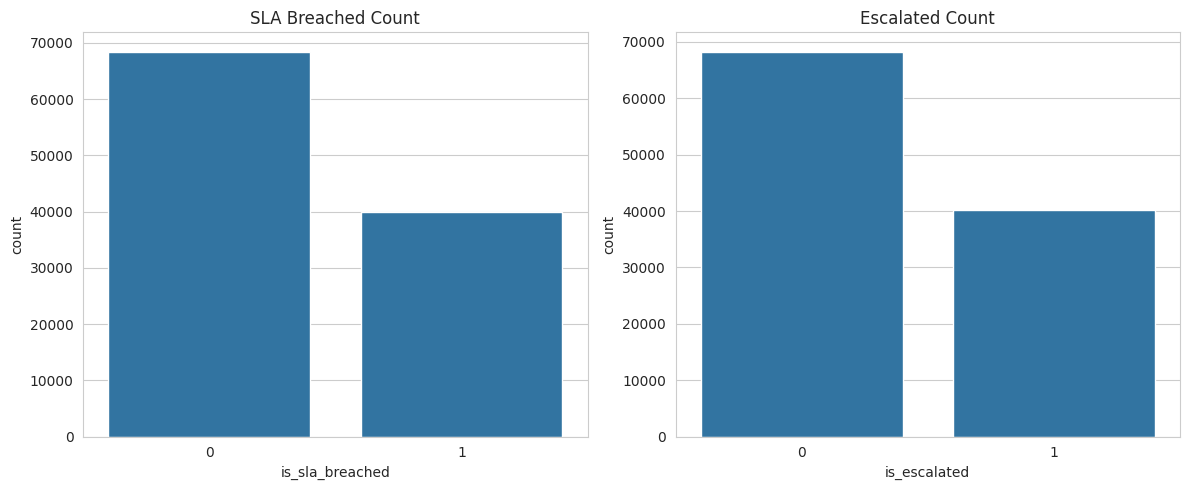

In [20]:
# ============================================================
# CELL 18 — SLA BREACHED vs ESCALATED
# ============================================================

if "is_sla_breached" in df.columns and "is_escalated" in df.columns:

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.countplot(data=df, x="is_sla_breached", ax=axes[0])
    axes[0].set_title("SLA Breached Count")

    sns.countplot(data=df, x="is_escalated", ax=axes[1])
    axes[1].set_title("Escalated Count")

    plt.tight_layout()
    plt.show()

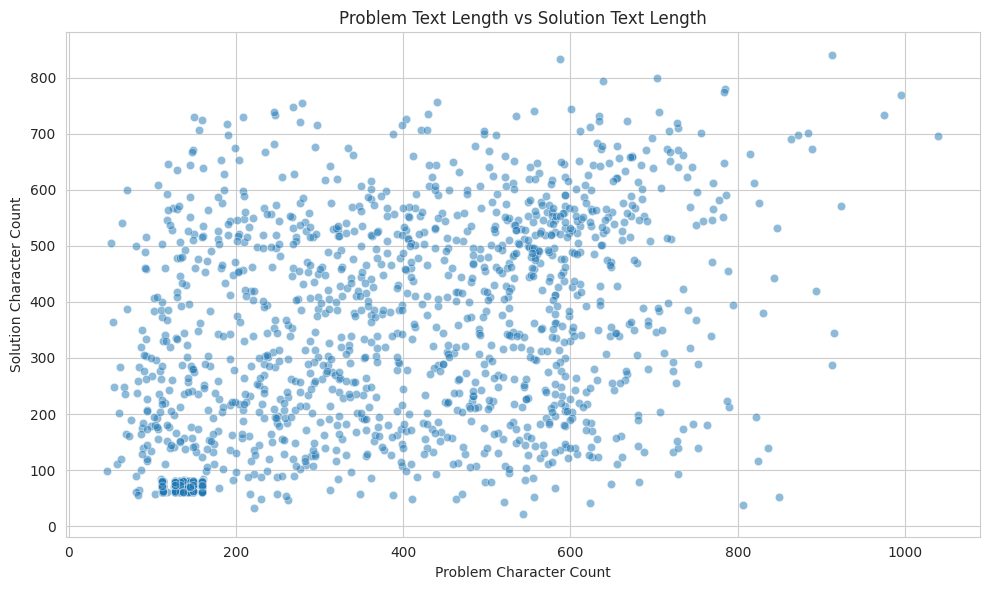

In [21]:
# ============================================================
# CELL 19 — PROBLEM vs SOLUTION LENGTH SCATTER
# ============================================================

if (
    "problem_text_clean" in df.columns
    and
    "solution_text_clean" in df.columns
):
    sample = df.sample(min(5000, len(df))).copy()
    sample["problem_len"] = sample["problem_text_clean"].str.len()
    sample["solution_len"] = sample["solution_text_clean"].str.len()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=sample,
        x="problem_len",
        y="solution_len",
        alpha=0.5
    )

    plt.title("Problem Text Length vs Solution Text Length")
    plt.xlabel("Problem Character Count")
    plt.ylabel("Solution Character Count")

    plt.tight_layout()
    plt.show()

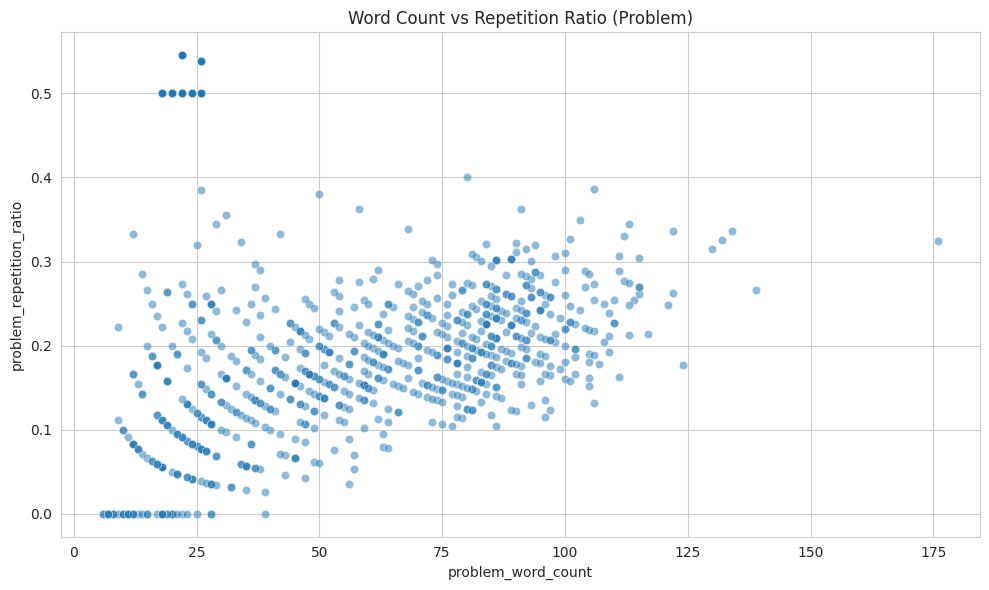

In [22]:
# ============================================================
# CELL 20 — WORD COUNT vs REPETITION RATIO
# ============================================================

if (
    "problem_word_count" in df.columns
    and
    "problem_repetition_ratio" in df.columns
):

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df.sample(min(3000, len(df))),
        x="problem_word_count",
        y="problem_repetition_ratio",
        alpha=0.5
    )

    plt.title("Word Count vs Repetition Ratio (Problem)")

    plt.tight_layout()
    plt.show()

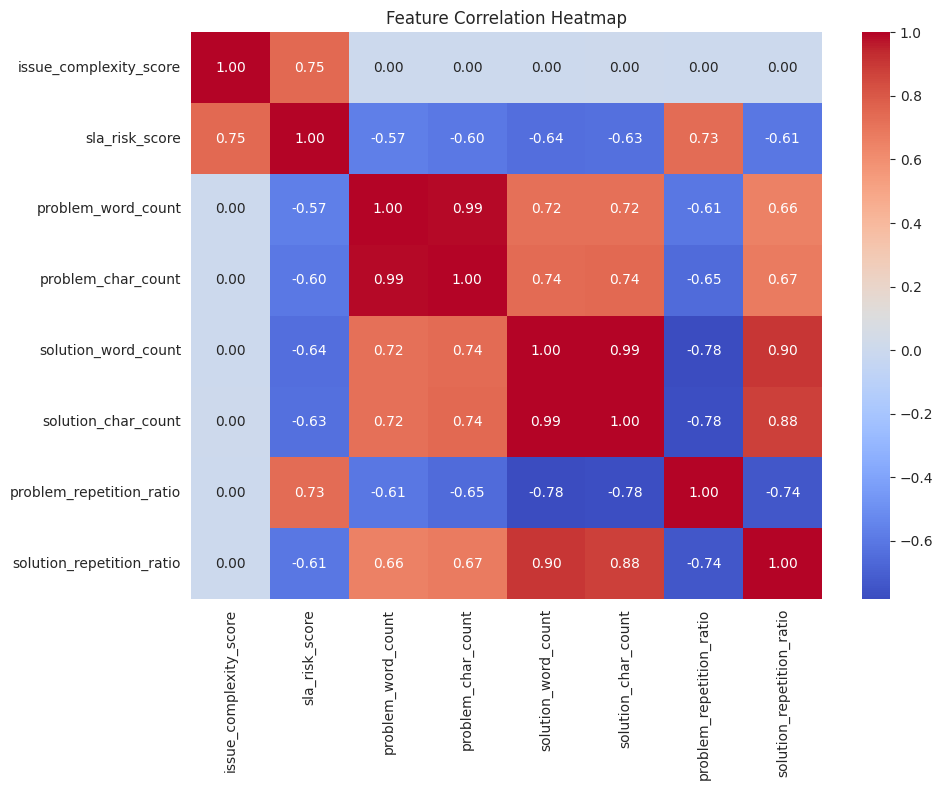

In [23]:
# ============================================================
# CELL 21 — CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    c for c in [
        "issue_complexity_score",
        "sla_risk_score",
        "problem_word_count",
        "problem_char_count",
        "solution_word_count",
        "solution_char_count",
        "problem_repetition_ratio",
        "solution_repetition_ratio"
    ]
    if c in df.columns
]

corr_df = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 22 — LONGEST TICKETS
# ============================================================

if (
    "problem_text_clean" in df.columns
    and
    "problem_char_count" in df.columns
):

    longest_tickets = (
        df.sort_values(
            by="problem_char_count",
            ascending=False
        )
        .head(5)
    )

    print("=" * 60)
    print("LONGEST TICKETS")
    print("=" * 60)

    display(
        longest_tickets[
            [
                "rag_id",
                "problem_char_count",
                "problem_text_clean"
            ]
        ]
    )

LONGEST TICKETS


,rag_id,problem_char_count,problem_text_clean
81885,deaba5a6a471f100efd62582b6043ac2,1512,anfrage zur architektur-dokumentation der saas...
3934,358c6bac471218455a3fa34bb058cbe2,1470,anfrage zur technischen dokumentation der saas...
16685,202c7f3a1a49e99a97cecfd1b2bf32d0,1371,eilt verf gbarkeitsst rung bei cloud-basiertem...
7454,d3416f63157dcd6e011e00c7751c2010,1240,geehrte kundenservice bitte beraten sie mich i...
54637,88ddd0970c06583bf1c39280fd2a7113,1213,liebe kundensupport ben tige detaillierte doku...


In [25]:
# ============================================================
# CELL 23 — HIGHEST ISSUE COMPLEXITY TICKETS
# ============================================================

if "issue_complexity_score" in df.columns:

    highest_complexity = (
        df.sort_values(
            by="issue_complexity_score",
            ascending=False
        )
        .head(10)
    )

    print("=" * 60)
    print("HIGHEST ISSUE COMPLEXITY TICKETS")
    print("=" * 60)

    display(
        highest_complexity[
            [
                "rag_id",
                "issue_complexity_score",
                "problem_text_clean"
            ]
        ]
    )

HIGHEST ISSUE COMPLEXITY TICKETS


,rag_id,issue_complexity_score,problem_text_clean
12,8e277d77431dc810d7971cd87a04cd9d,10.0,there seems to be a discrepancy in my billing ...
108181,5b1545258e0eaa6cc87d7aba30742821,10.0,the system is not syncing data across devices ...
108180,daad82d2ac90525fc0b500e541dc214c,10.0,the system is not syncing data across devices ...
108178,881d7c62ce5868158bb3f0cd510b5063,10.0,the payment was deducted from my bank account ...
108173,f9ad86a71ea0d5647188b03cabf49286,10.0,there seems to be a discrepancy in my billing ...
22,39a560ddae8ddbba9401c24a665ccd71,10.0,the application crashes whenever i try to uplo...
108169,efc3e7388b67b3d686ef2ca51ac57e05,10.0,i found a bug in the latest update affecting r...
108137,5f5fff883832d74e63a0aecc23f6974a,10.0,the payment was deducted from my bank account ...
21643,6d1cf12e95a561fbbf18573890e16624,10.0,i am unable to access my account after enterin...
21647,06e1189df18dc090a4297cd05fad5e6b,10.0,the system is not syncing data across devices ...


In [26]:
# ============================================================
# CELL 24 — LOWEST ISSUE COMPLEXITY TICKETS
# ============================================================

if "issue_complexity_score" in df.columns:

    lowest_complexity = (
        df.sort_values(
            by="issue_complexity_score",
            ascending=True
        )
        .head(10)
    )

    print("=" * 60)
    print("LOWEST ISSUE COMPLEXITY TICKETS")
    print("=" * 60)

    display(
        lowest_complexity[
            [
                "rag_id",
                "issue_complexity_score",
                "problem_text_clean"
            ]
        ]
    )

LOWEST ISSUE COMPLEXITY TICKETS


,rag_id,issue_complexity_score,problem_text_clean
59,979b0fccfd7015c85c57bae806d62f57,1.0,the system is not syncing data across devices ...
80,dcaf902af0f2b05531bb468112ea2c86,1.0,i would like to request a refund for the recen...
54013,6fff721d6a4e084cbade74b8b1cfe88e,1.0,my subscription was cancelled without my reque...
54024,9f9fc145899a3209a0304822a2a8d53d,1.0,my subscription was cancelled without my reque...
54034,bc23d4f4694a03df2dca43405e250912,1.0,i found a bug in the latest update affecting r...
54041,198cb1f6a511e2148b8ca4557bc6f8dd,1.0,there seems to be a discrepancy in my billing ...
54042,e04956daa519407dbc19b39a20d32320,1.0,i would like to request a refund for the recen...
54045,a81f07d5cdce60b3d0dabab0fd11c7c2,1.0,my subscription was cancelled without my reque...
10621,976e9ccb54b15745b51bddb9269daf13,1.0,there seems to be a discrepancy in my billing ...
97504,209680ca694bd36107670b42d421dd7d,1.0,two-factor authentication codes are not being ...


In [27]:
# ============================================================
# CELL 25 — RETRIEVAL CORPUS STATISTICS
# ============================================================

print("=" * 60)
print("RETRIEVAL CORPUS STATISTICS")
print("=" * 60)

print(f"Total Tickets                    : {len(df):,}")

if "problem_word_count" in df.columns:
    print(f"Average Problem Word Count       : {df['problem_word_count'].mean():.2f}")
    print(f"Median Problem Word Count        : {df['problem_word_count'].median():.2f}")

if "solution_word_count" in df.columns:
    print(f"Average Solution Word Count      : {df['solution_word_count'].mean():.2f}")
    print(f"Median Solution Word Count       : {df['solution_word_count'].median():.2f}")

if "problem_char_count" in df.columns:
    print(f"Average Problem Char Count       : {df['problem_char_count'].mean():.2f}")

if "solution_char_count" in df.columns:
    print(f"Average Solution Char Count      : {df['solution_char_count'].mean():.2f}")

if "problem_repetition_ratio" in df.columns:
    print(f"Average Problem Repetition Ratio : {df['problem_repetition_ratio'].mean():.4f}")

if "solution_repetition_ratio" in df.columns:
    print(f"Average Solution Repetition Ratio: {df['solution_repetition_ratio'].mean():.4f}")

if "source_system" in df.columns:
    print(f"Unique Source Systems            : {df['source_system'].nunique()}")

if "source_dataset" in df.columns:
    print(f"Unique Source Datasets            : {df['source_dataset'].nunique()}")

RETRIEVAL CORPUS STATISTICS
Total Tickets                    : 108,421
Average Problem Word Count       : 32.15
Median Problem Word Count        : 22.00
Average Solution Word Count      : 22.11
Median Solution Word Count       : 9.00
Average Problem Char Count       : 208.74
Average Solution Char Count      : 149.88
Average Problem Repetition Ratio : 0.4214
Average Solution Repetition Ratio: 0.0553
Unique Source Systems            : 2
Unique Source Datasets            : 2


In [28]:
# ============================================================
# CELL 26 — CLASS IMBALANCE ANALYSIS
# ============================================================

TARGET_COLUMNS = [
    "priority",
    "priority_tier"
]

for col in TARGET_COLUMNS:

    if col in df.columns:

        print("\n" + "=" * 60)
        print(f"{col.upper()} DISTRIBUTION")
        print("=" * 60)

        distribution = (
            df[col]
            .value_counts(normalize=True)
            .sort_index()
            * 100
        ).round(2)

        display(distribution)


PRIORITY DISTRIBUTION


priority
critical    18.54
high        28.70
low         23.74
medium      29.02
Name: proportion, dtype: float64

In [29]:
eda_summary = {
    "total_rows": len(df),
    "total_columns": df.shape[1],
    "avg_problem_word_count": round(
        df["problem_word_count"].mean(),
        2
    ),
    "median_problem_word_count": round(
        df["problem_word_count"].median(),
        2
    ),
    "avg_issue_complexity_score": round(
        df["issue_complexity_score"].mean(),
        2
    )
}

In [30]:
print("=" * 60)
print("RAG READINESS CHECK")
print("=" * 60)

print(
    "Documents for indexing:",
    len(df)
)

if "problem_word_count" in df.columns:
    print(
        "Average problem words:",
        round(df["problem_word_count"].mean(),2)
    )

if "solution_word_count" in df.columns:
    print(
        "Average solution words:",
        round(df["solution_word_count"].mean(),2)
    )

if "issue_complexity_score" in df.columns:
    print(
        "Average issue complexity:",
        round(df["issue_complexity_score"].mean(),2)
    )

RAG READINESS CHECK
Documents for indexing: 108421
Average problem words: 32.15
Average solution words: 22.11
Average issue complexity: 5.51


In [31]:
# ============================================================
# CELL last — EXPORT EDA SUMMARY
# ============================================================

duplicates = (
    df["problem_text_clean"].duplicated().sum()
    if "problem_text_clean" in df.columns
    else 0
)
duplicate_ratio = duplicates / len(df) * 100 if len(df) > 0 else 0

eda_summary = {
    "total_documents": len(df),
    "total_columns": df.shape[1],

    "avg_problem_word_count": round(
        df["problem_word_count"].mean(), 2
    ) if "problem_word_count" in df.columns else None,

    "median_problem_word_count": round(
        df["problem_word_count"].median(), 2
    ) if "problem_word_count" in df.columns else None,

    "max_problem_word_count": int(
        df["problem_word_count"].max()
    ) if "problem_word_count" in df.columns else None,

    "avg_problem_char_count": round(
        df["problem_char_count"].mean(), 2
    ) if "problem_char_count" in df.columns else None,

    "avg_solution_word_count": round(
        df["solution_word_count"].mean(), 2
    ) if "solution_word_count" in df.columns else None,

    "avg_solution_char_count": round(
        df["solution_char_count"].mean(), 2
    ) if "solution_char_count" in df.columns else None,

    "duplicate_problems": int(duplicates),
    "duplicate_ratio_pct": round(duplicate_ratio, 2),

    "avg_issue_complexity_score": round(
        df["issue_complexity_score"].mean(), 4
    ) if "issue_complexity_score" in df.columns else None,

    "min_issue_complexity_score": round(
        df["issue_complexity_score"].min(), 4
    ) if "issue_complexity_score" in df.columns else None,

    "max_issue_complexity_score": round(
        df["issue_complexity_score"].max(), 4
    ) if "issue_complexity_score" in df.columns else None
}

eda_summary_df = pd.DataFrame([eda_summary])

OUTPUT_DIR = Path("../../evaluation_v2/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUTPUT_DIR / "eda_summary_v2.csv"

eda_summary_df.to_csv(summary_path, index=False)

print(f"EDA summary saved to: {summary_path}")
display(eda_summary_df)

EDA summary saved to: ../../evaluation_v2/eda_summary_v2.csv


,total_documents,total_columns,avg_problem_word_count,median_problem_word_count,max_problem_word_count,avg_problem_char_count,avg_solution_word_count,avg_solution_char_count,duplicate_problems,duplicate_ratio_pct,avg_issue_complexity_score,min_issue_complexity_score,max_issue_complexity_score
0,108421,31,32.15,22.0,201,208.74,22.11,149.88,79989,73.78,5.5107,1.0,10.0
